In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Data Fusion and Integration

#### Ex1: (Challenges 3 & 4)

In [33]:
electric_df = pd.read_csv('Electricity Data 2016_2017.csv')
temp_df = pd.read_csv('Temperature 2016.csv')

In [34]:
electric_df.head(3)

,Date,Time,Consumption
0,12/1/2017,0:00:00,72650.0
1,12/1/2017,0:15:00,72524.0
2,12/1/2017,0:30:00,70553.0


In [35]:
electric_df.tail(3)

,Date,Time,Consumption
38109,1/1/2016,23:15,NaN
38110,1/1/2016,23:30,57539.0
38111,1/1/2016,23:45,NaN


In [36]:
electric_df.shape

(38112, 3)

In [37]:
temp_df.head(3)

,Timestamp,temp
0,2016-01-01T00:00:00,79.0
1,2016-01-01T01:00:00,79.0
2,2016-01-01T02:00:00,77.5


In [38]:
temp_df.tail(3)

,Timestamp,temp
8728,2016-12-31T21:00:00,77.0
8729,2016-12-31T22:00:00,77.0
8730,2016-12-31T23:00:00,77.0


In [39]:
temp_df.shape

(8731, 2)

* Both electric_df and temp_df have a timestamp in column.
* Electric_df is on a 15 minute split from 2016-2017
* Temp_df is on an hour split from 2016
* Electric_df would have to be summarized to at least an hour split

In [40]:
# Remove 2017 data from electric_df
BM = electric_df.Date.str.contains('2017')
dropping_index = electric_df[BM].index
electric_df.drop(index=dropping_index, inplace=True)

In [41]:
electric_df.head(3)

,Date,Time,Consumption
2976,12/31/2016,0:00,74259.0
2977,12/31/2016,0:15,NaN
2978,12/31/2016,0:30,72715.0


In [43]:
# Create hour field based on the Time field
electric_df['Hour'] = electric_df['Time'].apply(lambda v: '{}:00'.format(v.split(':')[0]))
electric_df.head(5)

,Date,Time,Consumption,Hour
2976,12/31/2016,0:00,74259.0,0:00
2977,12/31/2016,0:15,NaN,0:00
2978,12/31/2016,0:30,72715.0,0:00
2979,12/31/2016,0:45,NaN,0:00
2980,12/31/2016,1:00,70283.0,1:00


In [46]:
# Group electric_df by date and hour. sum by consumption
integrate_sr = electric_df.groupby(["Date","Hour"])["Consumption"].sum()
integrate_sr.head(5)

Date      Hour 
1/1/2016  0:00     119052.0
          10:00    101915.0
          11:00    105796.0
          12:00    109960.0
          13:00    112189.0
Name: Consumption, dtype: float64

In [49]:
# Create function to take the temp_df datafame and
# create the hour and date fields from the timestamp field
def unpackTimestamp(r):
    ts = r.Timestamp
    date, time = ts.split('T')
    hour = time.split(':')[0]
    year,month,day = date.split('-')
    
    r['Hour'] = '{}:00'.format(int(hour))
    r['Date'] = '{}/{}/{}'.format(
        int(month),int(day),year)
    return(r)

In [50]:
# Apply the function unpackTimestamp to temp_df
temp_df = temp_df.apply(unpackTimestamp, axis=1)

In [52]:
# Change the index to Date and Hour
# Drop the Timestamp field
temp_df = temp_df.set_index(['Date','Hour']).drop(columns=['Timestamp'])

In [53]:
temp_df.head(3)

temp
Date     Hour      
1/1/2016 0:00  79.0
         1:00  79.0
         2:00  77.5

In [54]:
# Join the integrate_sr dataframe to the temp_df dataframe
integrate_df = temp_df.join(integrate_sr)

In [55]:
integrate_df.head(3)

temp  Consumption
Date     Hour                   
1/1/2016 0:00  79.0     119052.0
         1:00  79.0     113138.0
         2:00  77.5     111013.0

In [57]:
integrate_df.shape

(8731, 2)

In [58]:
# Reset the index of the integrate_df dataframe
integrate_df.reset_index(inplace=True)

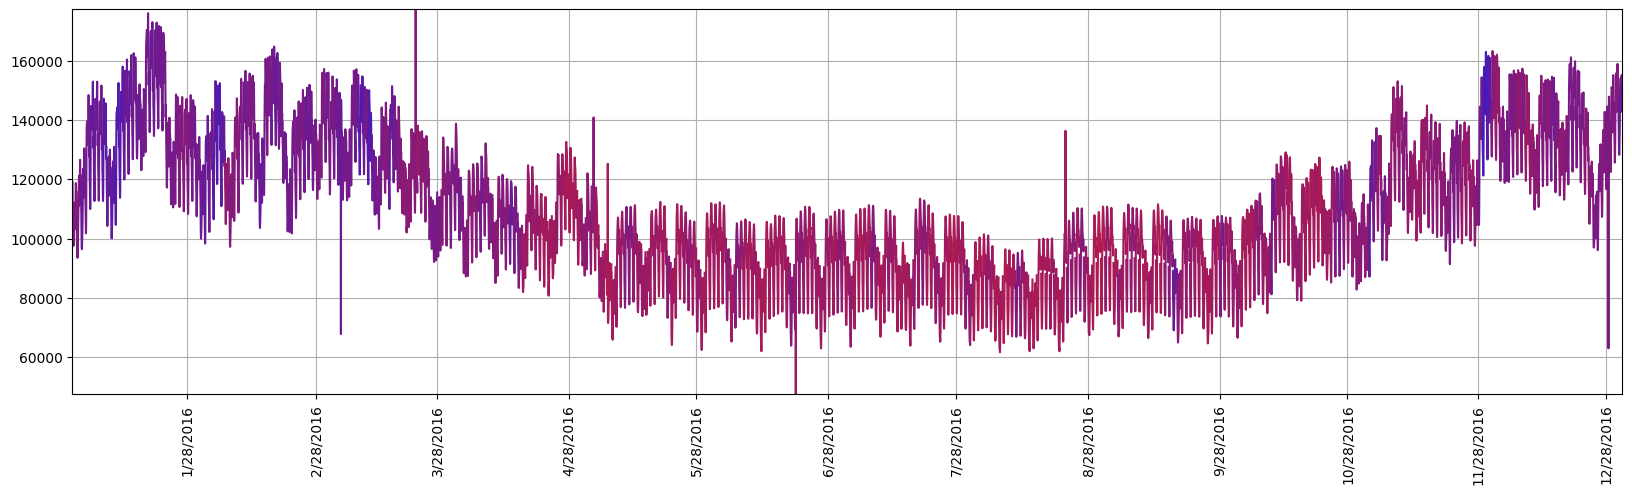

In [67]:
days = integrate_df.Date.unique()

max_temp, min_temp = integrate_df['temp'].max(), integrate_df['temp'].min()
green = 0.1

plt.figure(figsize=(20,5))

for d in days:
    BM = integrate_df['Date'] == d
    wdf = integrate_df[BM]
    
    average_temp = wdf['temp'].mean()
    
    #normalize the temp field values
    red = (average_temp - min_temp)/(max_temp-min_temp)
    blue = 1-red
    clr = [red,green,blue]
    plt.plot(wdf.index, wdf.Consumption, c=clr)
BM = (integrate_df['Hour'] == '0:00') & \
     (integrate_df['Date'].str.contains('/28/'))
plt.xticks(integrate_df[BM].index, 
           integrate_df[BM].Date,
           rotation = 90)
plt.grid()
plt.margins(y=0,x=0)
plt.show()

In [68]:
integrate_df['temp'].max()

93.0

In [69]:
integrate_df['temp'].min()

66.0

In [70]:
wdf.index

Index([8707, 8708, 8709, 8710, 8711, 8712, 8713, 8714, 8715, 8716, 8717, 8718,
       8719, 8720, 8721, 8722, 8723, 8724, 8725, 8726, 8727, 8728, 8729, 8730],
      dtype='int64')

In [73]:
wdf.Consumption.sum()

3450789.0

In [76]:
wdf.groupby(['Hour'])['Consumption'].sum()

Hour
0:00     146974.0
10:00    149228.0
11:00    150911.0
12:00    152809.0
13:00    154153.0
14:00    149138.0
15:00    144464.0
16:00    142980.0
17:00    147179.0
18:00    155157.0
19:00    154958.0
1:00     140264.0
20:00    149484.0
21:00    143693.0
22:00    142717.0
23:00    150928.0
2:00     138123.0
3:00     132228.0
4:00     128366.0
5:00     128275.0
6:00     130920.0
7:00     134707.0
8:00     139168.0
9:00     143965.0
Name: Consumption, dtype: float64

In [75]:
wdf.Date.unique()

array(['12/31/2016'], dtype=object)

#### Ex2: (Challenges 2 & 3)

In [77]:
athlete_df = pd.read_csv('table1.csv')
athlete_df

,Participant ID,Sex,Age,Weight (kg),Experience (years),Belt
0,P1,M,7,25,1,Green
1,P2,M,9,23,2,Red Stripe
2,P3,M,13,39,6,Black Stripe
3,P4,M,14,43,8,Black (Competitive)
4,P5,F,16,54,8,Black (Competitive)
5,P6,M,16,72,13,Black (Competitive)


In [78]:
unknown_df = pd.read_csv('Taekwondo_Technique_Classification_Stats.csv')
unknown_df.head(5)

,Technique,R,R.1,R.2,R.3,R.4,R.5,R.6,R.7,R.8,...,P.20,P.21,P.22,P.23,P.24,P.25,P.26,P.27,P.28,P.29
0,ID,P1,P1,P1,P1,P1,P2,P2,P2,P2,...,P5,P5,P5,P5,P5,P6,P6,P6,P6,P6
1,Trial #,1,2,3,4,5,1,2,3,4,...,1,2,3,4,5,1,2,3,4,5
2,Readings,1026,1026,1026,1026,1026,1026,1026,1026,1026,...,1026,1026,1026,1026,1026,1026,1026,1026,1026,1026
3,NaN,1026,1028,1026,1027,1027,1026,1026,1026,1026,...,1026,1028,1026,1026,1025,1026,1026,1026,1026,1026
4,NaN,1026,1028,1026,1026,1027,1026,1026,1026,1026,...,1026,1028,1026,1026,1025,1025,1026,1026,1026,1025


In [79]:
# create a new dataframe where the 116 columns in unknown_df will become rows
designed_columns = ['Participant_id','Gender','Age','Weight','Experience','Technique_id','Trial_number','Average_read']
n_rows = len(unknown_df.columns)-1

# create an empty dataframe to store the data of both objects
performance_df = pd.DataFrame(index=range(n_rows),columns=designed_columns)

In [81]:
performance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Participant_id  0 non-null      object
 1   Gender          0 non-null      object
 2   Age             0 non-null      object
 3   Weight          0 non-null      object
 4   Experience      0 non-null      object
 5   Technique_id    0 non-null      object
 6   Trial_number    0 non-null      object
 7   Average_read    0 non-null      object
dtypes: object(8)
memory usage: 7.3+ KB


In [83]:
# set the index values at the 'Participant ID'
athlete_df.set_index('Participant ID', inplace=True)

# rename the columns
athlete_df.columns = ['Sex','Age','Weight','Experience', 'Belt']

In [84]:
athlete_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, P1 to P6
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sex         6 non-null      object
 1   Age         6 non-null      int64 
 2   Weight      6 non-null      int64 
 3   Experience  6 non-null      int64 
 4   Belt        6 non-null      object
dtypes: int64(3), object(2)
memory usage: 288.0+ bytes


In [86]:
techniques = ['R','B','C','P']
index=0
for col in unknown_df.columns:
    # if a column field is one of the technique values...
    if(col[0] in techniques):
        performance_df.loc[index,'Technique_id'] = col[0]
        performance_df.loc[index,'Trial_number'] = unknown_df[col][1]
        
        # Set the P_id  as the participant id to link to athlete_df
        P_id = unknown_df[col][0]
        performance_df.loc[index,'Participant_id'] = P_id
        performance_df.loc[index,'Gender'] = athlete_df.loc[P_id]['Sex']
        performance_df.loc[index,'Age'] = athlete_df.loc[P_id]['Age']
        performance_df.loc[index,'Weight'] = athlete_df.loc[P_id]['Weight']
        performance_df.loc[index,'Experience'] = athlete_df.loc[P_id]['Experience']
        
        BM = unknown_df[col][2:].isna()
        
        # calculate the average read of rows 2 till the end while
        # ignoring the missing values in the column
        performance_df.loc[
            index,'Average_read'] = unknown_df[col][2:][~BM].astype(int).mean()
        index +=1

In [87]:
performance_df.head(3)

,Participant_id,Gender,Age,Weight,Experience,Technique_id,Trial_number,Average_read
0,P1,M,7,25,1,R,1,1026.112369
1,P1,M,7,25,1,R,2,1026.154806
2,P1,M,7,25,1,R,3,1026.106672


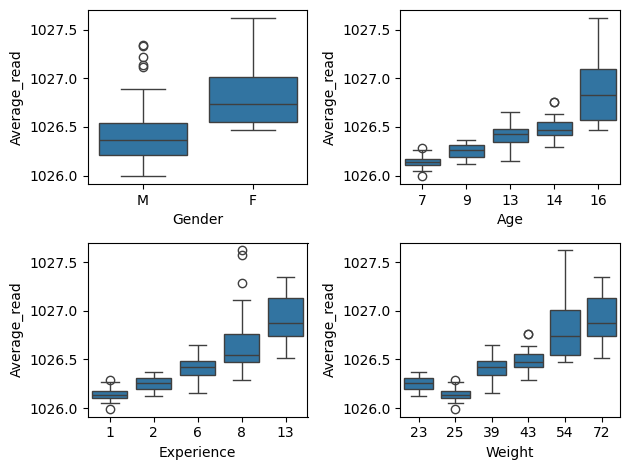

In [88]:
select_attributes = ['Gender','Age','Experience','Weight']
for i, att in enumerate(select_attributes):
    plt.subplot(2,2,i+1)
    sns.boxplot(data = performance_df,
                y='Average_read',
                x=att)
plt.tight_layout()
plt.show()

<Axes: xlabel='Experience', ylabel='Average_read'>

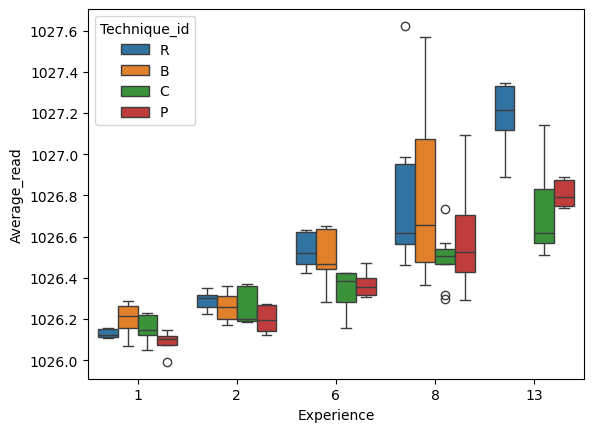

In [89]:
sns.boxplot(data = performance_df,
            y='Average_read',
            x='Experience',
            hue = 'Technique_id')

### Ex3: (Challenges 1,3,5 & 6)

#### Load the 3 files

In [95]:
billboard_df = pd.read_csv('billboardHot100_1999-2019.csv')
billboard_df.head(3)

,Unnamed: 0,Artists,Name,Weekly.rank,Peak.position,Weeks.on.chart,Week,Date,Genre,Writing.Credits,Lyrics,Features
0,1,"Lil Nas,",Old Town Road,1,1.0,7.0,2019-07-06,"April 5, 2019","Country,Atlanta,Alternative Country,Hip-Hop,Tr...","Jozzy, Atticus ross, Trent reznor, Billy ray c...","Old Town Road Remix \nOh, oh-oh\nOh\nYeah, I'm...",Billy Ray Cyrus
1,2,"Shawn Mendes, Camila Cabello",Senorita,2,NaN,NaN,2019-07-06,"June 21, 2019",Pop,"Cashmere cat, Jack patterson, Charli xcx, Benn...",Senorita \nI love it when you call me senorita...,NaN
2,3,Billie Eilish,Bad Guy,3,2.0,13.0,2019-07-06,"March 29, 2019","Hip-Hop,Dark Pop,House,Trap,Memes,Alternative ...","Billie eilish, Finneas","bad guy \nWhite shirt now red, my bloody nose\...",NaN


In [102]:
billboard_df['Artists']

0                            Lil Nas,
1        Shawn Mendes, Camila Cabello
2                       Billie Eilish
3                              Khalid
4           Ed Sheeran, Justin Bieber
                     ...             
97220                       Vitamin C
97221                 Collective Soul
97222           Mary Chapin Carpenter
97223                               Q
97224                   The Offspring
Name: Artists, Length: 97225, dtype: object

In [94]:
songAttribute_df = pd.read_csv('songAttributes_1999-2019.csv')
songAttribute_df.head(3)

,Unnamed: 0,Acousticness,Album,Artist,Danceability,Duration,Energy,Explicit,Instrumentalness,Liveness,Loudness,Mode,Name,Popularity,Speechiness,Tempo,TimeSignature,Valence
0,0,0.000728,Collective Soul (Deluxe Version),Collective Soul,0.520,234947,0.904,False,0.010300,0.0634,-5.030,1,Welcome All Again,35,0.0309,106.022,4,0.365
1,1,0.018200,Collective Soul (Deluxe Version),Collective Soul,0.581,239573,0.709,False,0.000664,0.1740,-4.909,1,Fuzzy,31,0.0282,120.027,4,0.408
2,2,0.000473,Collective Soul (Deluxe Version),Collective Soul,0.572,198400,0.918,False,0.000431,0.0977,-3.324,0,Dig,30,0.0559,144.061,4,0.370


In [98]:
artist_df = pd.read_csv('artistDf.csv')
artist_df.head(3)

,X,Artist,Followers,Genres,NumAlbums,YearFirstAlbum,Gender,Group.Solo
0,0,Ed Sheeran,52698756,"pop,uk pop",8,2011,M,Solo
1,1,Justin Bieber,30711450,"canadian pop,dance pop,pop,post-teen pop",10,2009,M,Solo
2,2,Jonas Brothers,3069527,"boy band,dance pop,pop,post-teen pop",10,2006,M,Group


 * Unnamed fields from songAttribute_df and billboard_df do not align
 * billboard_df and songAttribute_df appear to link by 
     * Artists (B) to Artist (SA)
     * Name (B) to Name (SA)
 * artist_df and songAttribute_df appear to lnnk by
     * Artist (A) to Artist (SA)

#### Check for duplicates in billboard_df

In [107]:
wsr = billboard_df.apply(lambda r: '{}-{}-{}'
                         .format(r['Artists'],r['Name'], r['Week']),axis=1)
wsr.value_counts()

50 Cent-Outta Control-2005-09-14                     2
Lil Nas,-Old Town Road-2019-07-06                    1
Carrie Underwood-Jesus, Take The Wheel-2006-04-12    1
The Black Eyed Peas-My Humps-2006-04-12              1
Chris Brown-Run It!-2006-04-12                       1
                                                    ..
T.I.-Ball-2012-12-21                                 1
Bruno Mars-When I Was Your Man-2012-12-21            1
Jake Owen-The One That Got Away-2012-12-21           1
Muse-Madness-2012-12-21                              1
The Offspring-Why Don't You Get A Job?-1999-07-12    1
Name: count, Length: 97224, dtype: int64

In [133]:
# Check the dataframe for duplicate records
wsr[wsr.duplicated()]

67647    50 Cent-Outta Control-2005-09-14
dtype: object

In [136]:
billboard_df.query("Artists == '50 Cent' and \
                     Name == 'Outta Control' and \
                     Week == '2005-09-14'")

,Unnamed: 0,Artists,Name,Weekly.rank,Peak.position,Weeks.on.chart,Week,Date,Genre,Writing.Credits,Lyrics,Features
67588,67589,50 Cent,Outta Control,25,25.0,9.0,2005-09-14,"August 6, 2005","Remix,Rap","Mark batson, Mike elizondo, Havoc, Prodigy of ...","Outta Control Remix \nIt's the Infamous Mobb, ...",Mobb Deep
67647,67648,50 Cent,Outta Control,92,NaN,NaN,2005-09-14,"August 6, 2005","Remix,Rap","Mark batson, Mike elizondo, Havoc, Prodigy of ...","Outta Control Remix \nIt's the Infamous Mobb, ...",NaN


In [137]:
# drop one of the duplicated records
billboard_df.drop(index= 67588, inplace = True)

#### Check for duplicates in songAttribute_df

In [143]:
wsr = songAttribute_df.apply(lambda r: '{}---{}'.
                            format(r['Artist'],r['Name']), axis=1)

In [149]:
# Check the dataframe for duplicate records
wsr.duplicated().sum()

23554

In [150]:
songAttribute_df.query("Artist == 'Jose Feliciano' and \
                       Name == 'Light My Fire'").head(3)

,Unnamed: 0,Acousticness,Album,Artist,Danceability,Duration,Energy,Explicit,Instrumentalness,Liveness,Loudness,Mode,Name,Popularity,Speechiness,Tempo,TimeSignature,Valence
143203,11,0.456,Encore! Jose Feliciano's Finest Performances (...,Jose Feliciano,0.569,374507,0.591,False,0.001030,0.678,-9.102,0,Light My Fire,3,0.0458,114.025,4,0.630
143275,83,0.454,Absolutely The Best: Jose Feliciano,Jose Feliciano,0.553,185986,0.470,False,0.000028,0.449,-16.280,0,Light My Fire,2,0.0427,109.038,4,0.770
143298,106,0.437,Affirmation,Jose Feliciano,0.558,188600,0.633,False,0.000011,0.402,-11.161,1,Light My Fire,1,0.0478,109.009,4,0.722


In [151]:
import time

In [166]:
doFrequencies = wsr.value_counts()

BM = doFrequencies>1
n_totalSongs = sum(BM)
print('Total processings: ' + str(n_totalSongs))

t = time.time()
i_progress = 0
for i,v in doFrequencies[BM].items():
    [name,artist] = i.split('---')
    BM = ((songAttribute_df.Name == name) & 
          (songAttribute_df.Artist == artist))
    wdf = songAttribute_df[BM]
    dropping_index = wdf.index[1:]
    songAttribute_df.drop(index=dropping_index, inplace=True)
    
    i_progress +=1
    if i_progress%3000==0:
        print('Processed:' + str(i_progress))
        process_time = time.time()-t
        print('Elapsed: ' + str(round(process_time,1)) + ' s')
        estimate_finish = round((n_totalSongs-i_progress) *
                                (process_time/3000)/60,1)
        
        print('To finish: ' + str(estimate_finish)+ 'mins')
        t = time.time()
        print('--------------------------------------')
        

Total processings: 17193
Processed:3000
Elapsed: 116.5 s
To finish: 9.2mins
--------------------------------------
Processed:6000
Elapsed: 114.8 s
To finish: 7.1mins
--------------------------------------
Processed:9000
Elapsed: 124.0 s
To finish: 5.6mins
--------------------------------------
Processed:12000
Elapsed: 120.7 s
To finish: 3.5mins
--------------------------------------
Processed:15000
Elapsed: 119.6 s
To finish: 1.5mins
--------------------------------------


In [170]:
# Check for duplicates in songAttribute_df
wsr = songAttribute_df.apply(lambda r: '{}---{}'.
                            format(r['Artist'],r['Name']), axis=1)
wsr.duplicated().sum()

0

#### Checking for duplicates in artist_df

In [179]:
artist_df[artist_df['Artist'].duplicated()]

,X,Artist,Followers,Genres,NumAlbums,YearFirstAlbum,Gender,Group.Solo
716,716,Reba McEntire,974392,"contemporary country,country,country dawn",40,1977,F,Solo


In [180]:
artist_df.query("Artist == 'Reba McEntire'")

,X,Artist,Followers,Genres,NumAlbums,YearFirstAlbum,Gender,Group.Solo
398,398,Reba McEntire,974392,"contemporary country,country,country dawn",40,1977,F,Solo
716,716,Reba McEntire,974392,"contemporary country,country,country dawn",40,1977,F,Solo


In [181]:
# Drop one of the duplicated artist rows
artist_df.drop(index=716, inplace=True)

In [182]:
# check the drop was successful
artist_df[artist_df['Artist'].duplicated()]

,X,Artist,Followers,Genres,NumAlbums,YearFirstAlbum,Gender,Group.Solo


### Design the structure for the end result of data integration

In [201]:
songIntegrate_df = pd.DataFrame(
    columns = ['Name', 'Artists', 'Top_song', 'First_date_on_Billboard',
               'Acousticness', 'Danceability', 'Duration', 'Energy',
               'Explicit', 'Instrumentalness', 'Liveness', 'Loudness',
               'Mode', 'Speechiness', 'Tempo', 'TimeSignature', 'Valence',
               'Artists_n_followers', 'n_male_artists', 'n_female_artists',
               'n_bands', 'artist_average_years_after_first_album',
               'artist_average_number_albums'])
songIntegrate_df

,Name,Artists,Top_song,First_date_on_Billboard,Acousticness,Danceability,Duration,Energy,Explicit,Instrumentalness,...,Speechiness,Tempo,TimeSignature,Valence,Artists_n_followers,n_male_artists,n_female_artists,n_bands,artist_average_years_after_first_album,artist_average_number_albums


### Filling songIntegrate_df from billboard_df

In [202]:
# Get the unique song names from billboard_df
SongNames = billboard_df.Name.unique()


for i, song in enumerate(SongNames):
    # for each song, get the rows associated with the song
    BM = billboard_df['Name'] == song
    wdf = billboard_df[BM]
    
    # get the unique artists for each song name
    # a song name could have more than 1 artist
    Artists = wdf['Artists'].unique()
    for artist in Artists:
        
        # for each song/artist, get the rows associated
        BM = wdf['Artists'] == artist
        wdf2 = wdf[BM]
        
        # set the topsong variable to False
        topsong = False
        
        # filter for only artists songs that were in the top 10
        BM = wdf2['Weekly.rank'] <=10
        
        # If the number of rows for an artist's song is greater
        # than or equal to 5, set the topsong variable to True as
        # this indicates the song was in the top 10 for 5 or 
        # more weeks
        if(len(wdf2[BM])>=5):
            topsong=True
        
        # get the first date on billboard from the last row of Week field
        first_date_on_billboard = wdf2['Week'].iloc[-1]
        
        # set a dictionary to contain the 4 fields to update songIntegrate_df
        dic_append = {'Name':song,
                      'Artists':artist,
                      'Top_song':topsong,
                      'First_date_on_Billboard':first_date_on_billboard}
        
        # update the songIntergrate_df 
        songIntegrate_df.loc[len(songIntegrate_df)] = dic_append

In [203]:
songIntegrate_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7213 entries, 0 to 7212
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Name                                    7213 non-null   object 
 1   Artists                                 7213 non-null   object 
 2   Top_song                                7213 non-null   bool   
 3   First_date_on_Billboard                 7213 non-null   object 
 4   Acousticness                            0 non-null      float64
 5   Danceability                            0 non-null      float64
 6   Duration                                0 non-null      float64
 7   Energy                                  0 non-null      float64
 8   Explicit                                0 non-null      float64
 9   Instrumentalness                        0 non-null      float64
 10  Liveness                                0 non-null      float64
 

### Filling songiIntegrate_df from songAttribute_df

In [204]:
adding_columns = ['Acousticness','Danceability','Duration','Energy','Explicit','Instrumentalness',
                  'Liveness','Loudness','Mode','Speechiness','Tempo','TimeSignature', 'Valence']

for i, row in songIntegrate_df.iterrows():
    filled =False
    Artists = row.Artists.split(',')
    Artists = list(map(str.strip, Artists))
    
    # Situation 1
    # one artist and one song matching both sides
    BM = songAttribute_df.Name == row.Name
    if(sum(BM) == 1):
        for col in adding_columns:
            songIntegrate_df.loc[i,col] = songAttribute_df[BM][col].values[0]
        filled = True
    
    # Situation 2
    # more than 1 song in songAttribute_df but only 1 artist
    # in the SongIntegrate_df side that matches or is contained in 
    # one of the songs' artists in songAttribute_df
    elif(sum(BM)>1):
        wdf = songAttribute_df[BM]
        if(len(Artists)==1):
            BM2 = wdf['Artist'].str.contains(Artists[0])
            if(sum(BM2)==1):
                for col in adding_columns:
                    songIntegrate_df.loc[i, col]=wdf[BM2][col].values[0]
                    filled = True
    
    # Situation 3
    # songIntegrate has a song with more than 1 artist
    # the song name in songIntegrate is within the song name of songAttribute_df
    # and the artist of songAttribute is in the Artists list of songIntegrate
    if((not filled) and len(Artists)>1):
        BM2= (songAttribute_df['Name'].str.contains(row.Name)&
              songAttribute_df['Artist'].isin(Artists))
        if(sum(BM2)==1):
            for col in adding_columns:
                songIntegrate_df.loc[i,col]= songAttribute_df[BM2][col].values[0]
            filled = True
    
    # For remaining songIntegrate recods without a match...
    if (not filled):
        # Situation 4
        # The song name of songIntegrate is contained within a name of songAttribute
        # and the artist in the songIntegrate list matches an artist name
        # in the songAttribute
        BM2 = songAttribute_df.Name.str.contains(row.Name)
        if(sum(BM2)==1):
            for artist in Artists:
                if(artist == songAttribute_df[BM2].Artist.iloc[0]):
                    for col in adding_columns:
                        songIntegrate_df.loc[i,col]= songAttribute_df[BM2][col].values[0]
                    filled = True
       
        # Situation 5
        # Songs that have more than 1 artist in songIntegrate but 1
        # does match artist in songAttribute and the song names match
        if(sum(BM2)>1):
            wdf2 = songAttribute_df[BM2]
            BM3 = wdf2.Artist.isin(Artists)
            if(sum(BM3)>0):
                wdf3 = wdf2[BM3]
                for i3, row3 in wdf3.iterrows():
                    if(row3.Name == row.Name):
                        for col in adding_columns:
                            songIntegrate_df.loc[i,col]= row3[col]
                        filled = True
            

In [205]:
songIntegrate_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7213 entries, 0 to 7212
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Name                                    7213 non-null   object 
 1   Artists                                 7213 non-null   object 
 2   Top_song                                7213 non-null   bool   
 3   First_date_on_Billboard                 7213 non-null   object 
 4   Acousticness                            4045 non-null   float64
 5   Danceability                            4045 non-null   float64
 6   Duration                                4045 non-null   float64
 7   Energy                                  4045 non-null   float64
 8   Explicit                                4045 non-null   object 
 9   Instrumentalness                        4045 non-null   float64
 10  Liveness                                4045 non-null   float64
 

In [207]:
# Find the unmatched records from using songAttribute_df and 
# determine if they have a relationship with the Top_song field
B_MV = songIntegrate_df['Acousticness'].isna()
B_MV.rename('Missing Values', inplace=True)
contingency_table = pd.crosstab(songIntegrate_df['Top_song'], B_MV)
contingency_table

Missing Values,False,True
Top_song,,
False,3618,2874
True,427,294


In [209]:
from scipy.stats import chi2_contingency
p_value = chi2_contingency(contingency_table)[1]
p_value

0.07952275342130063

In [210]:
# p-value from above is not lower than 0.05, therefore there is
# no relationship between the missing values and the Top_song
# So... the records with the missing values can be dropped as
# they will not impact the top song analysis
dropping_index = songIntegrate_df[B_MV].index
songIntegrate_df.drop(index=dropping_index, inplace=True)

In [211]:
songIntegrate_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4045 entries, 6 to 7211
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Name                                    4045 non-null   object 
 1   Artists                                 4045 non-null   object 
 2   Top_song                                4045 non-null   bool   
 3   First_date_on_Billboard                 4045 non-null   object 
 4   Acousticness                            4045 non-null   float64
 5   Danceability                            4045 non-null   float64
 6   Duration                                4045 non-null   float64
 7   Energy                                  4045 non-null   float64
 8   Explicit                                4045 non-null   object 
 9   Instrumentalness                        4045 non-null   float64
 10  Liveness                                4045 non-null   float64
 

### Filling songIntegrate_df from artist_df

In [212]:
artist_df.head(3)

,X,Artist,Followers,Genres,NumAlbums,YearFirstAlbum,Gender,Group.Solo
0,0,Ed Sheeran,52698756,"pop,uk pop",8,2011,M,Solo
1,1,Justin Bieber,30711450,"canadian pop,dance pop,pop,post-teen pop",10,2009,M,Solo
2,2,Jonas Brothers,3069527,"boy band,dance pop,pop,post-teen pop",10,2006,M,Group


In [213]:
artist_df = artist_df.set_index('Artist').drop(columns=['X'])

In [214]:
artist_df.loc['Drake']

Followers                                                  41420478
Genres            canadian hip hop,canadian pop,hip hop,pop rap,...
NumAlbums                                                        11
YearFirstAlbum                                                 2010
Gender                                                            M
Group.Solo                                                     Solo
Name: Drake, dtype: object

In [215]:
artist_df.index.values

array(['Ed Sheeran', 'Justin Bieber', 'Jonas Brothers', ...,
       'Lila McCann', 'Everlast', 'Collective Soul'], dtype=object)

In [216]:
for i,row in songIntegrate_df.iterrows():
    Artists = row.Artists.split(',')
    Artists = list(map(str.strip,Artists))
    ArtistsIn_artist_df = True
    for artist in Artists:
        if(artist not in artist_df.index.values):
            ArtistsIn_artist_df= False
            break
    if(not ArtistsIn_artist_df):
        continue

    songIntegrate_df.loc[i,'Artists_n_followers'] = 0
    songIntegrate_df.loc[i,'n_male_artists'] = 0
    songIntegrate_df.loc[i,'n_female_artists'] = 0
    songIntegrate_df.loc[i, 'artist_average_years_after_first_album'] = 0
    songIntegrate_df.loc[i, 'artist_average_number_albums'] = 0
    songIntegrate_df.loc[i,'n_bands'] = 0
        
    for artist in Artists:
        songIntegrate_df.loc[i,'Artists_n_followers'] += artist_df.loc[artist].Followers
        if(artist_df.loc[artist]['Group.Solo']=='Solo'):
            if(artist_df.loc[artist].Gender == 'M'):            
                songIntegrate_df.loc[i,'n_male_artists'] += 1
            if(artist_df.loc[artist].Gender == 'F'):
                songIntegrate_df.loc[i,'n_female_artists'] += 1

        if(artist_df.loc[artist]['Group.Solo']=='Group'):
            if(artist_df.loc[artist].Gender == 'M'):
                songIntegrate_df.loc[i,'n_male_artists'] += 2
            if(artist_df.loc[artist].Gender == 'F'):
                songIntegrate_df.loc[i,'n_female_artists'] += 2
            songIntegrate_df.loc[i,'n_bands'] += 1
        First_date_on_Billboard = int(row.First_date_on_Billboard[:4])
        songIntegrate_df.loc[i, 'artist_average_years_after_first_album'] += \
            (First_date_on_Billboard - int(artist_df.loc[artist].YearFirstAlbum))

        songIntegrate_df.loc[i,
            'artist_average_number_albums'] += int(artist_df.loc[artist].NumAlbums)
    
    songIntegrate_df.loc[i,'artist_average_years_after_first_album'] /= len(Artists)
    songIntegrate_df.loc[i, 'artist_average_number_albums'] /= len(Artists)

In [217]:
songIntegrate_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4045 entries, 6 to 7211
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Name                                    4045 non-null   object 
 1   Artists                                 4045 non-null   object 
 2   Top_song                                4045 non-null   bool   
 3   First_date_on_Billboard                 4045 non-null   object 
 4   Acousticness                            4045 non-null   float64
 5   Danceability                            4045 non-null   float64
 6   Duration                                4045 non-null   float64
 7   Energy                                  4045 non-null   float64
 8   Explicit                                4045 non-null   object 
 9   Instrumentalness                        4045 non-null   float64
 10  Liveness                                4045 non-null   float64
 

In [218]:
B_MV = songIntegrate_df['Artists_n_followers'].isna()
B_MV.rename('Missing Values',inplace=True)
contingency_table = pd.crosstab(songIntegrate_df.Top_song, B_MV)
contingency_table

Missing Values,False,True
Top_song,,
False,3280,338
True,392,35


In [219]:
from scipy.stats import chi2_contingency
p_value = chi2_contingency(contingency_table)[1]
p_value

0.4931640410927335

In [220]:
dropping_indices = songIntegrate_df[B_MV].index.values
songIntegrate_df.drop(index=dropping_indices, inplace=True)

In [221]:
songIntegrate_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3672 entries, 6 to 7211
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Name                                    3672 non-null   object 
 1   Artists                                 3672 non-null   object 
 2   Top_song                                3672 non-null   bool   
 3   First_date_on_Billboard                 3672 non-null   object 
 4   Acousticness                            3672 non-null   float64
 5   Danceability                            3672 non-null   float64
 6   Duration                                3672 non-null   float64
 7   Energy                                  3672 non-null   float64
 8   Explicit                                3672 non-null   object 
 9   Instrumentalness                        3672 non-null   float64
 10  Liveness                                3672 non-null   float64
 

### Checking for Data Redundancy
#### Check for data redundancy among numerical attribut

In [224]:
df_num_list = [songIntegrate_df.columns[x] for x in range(len(songIntegrate_df.columns)) 
               if songIntegrate_df.dtypes[x] in ('float64', 'int64')]

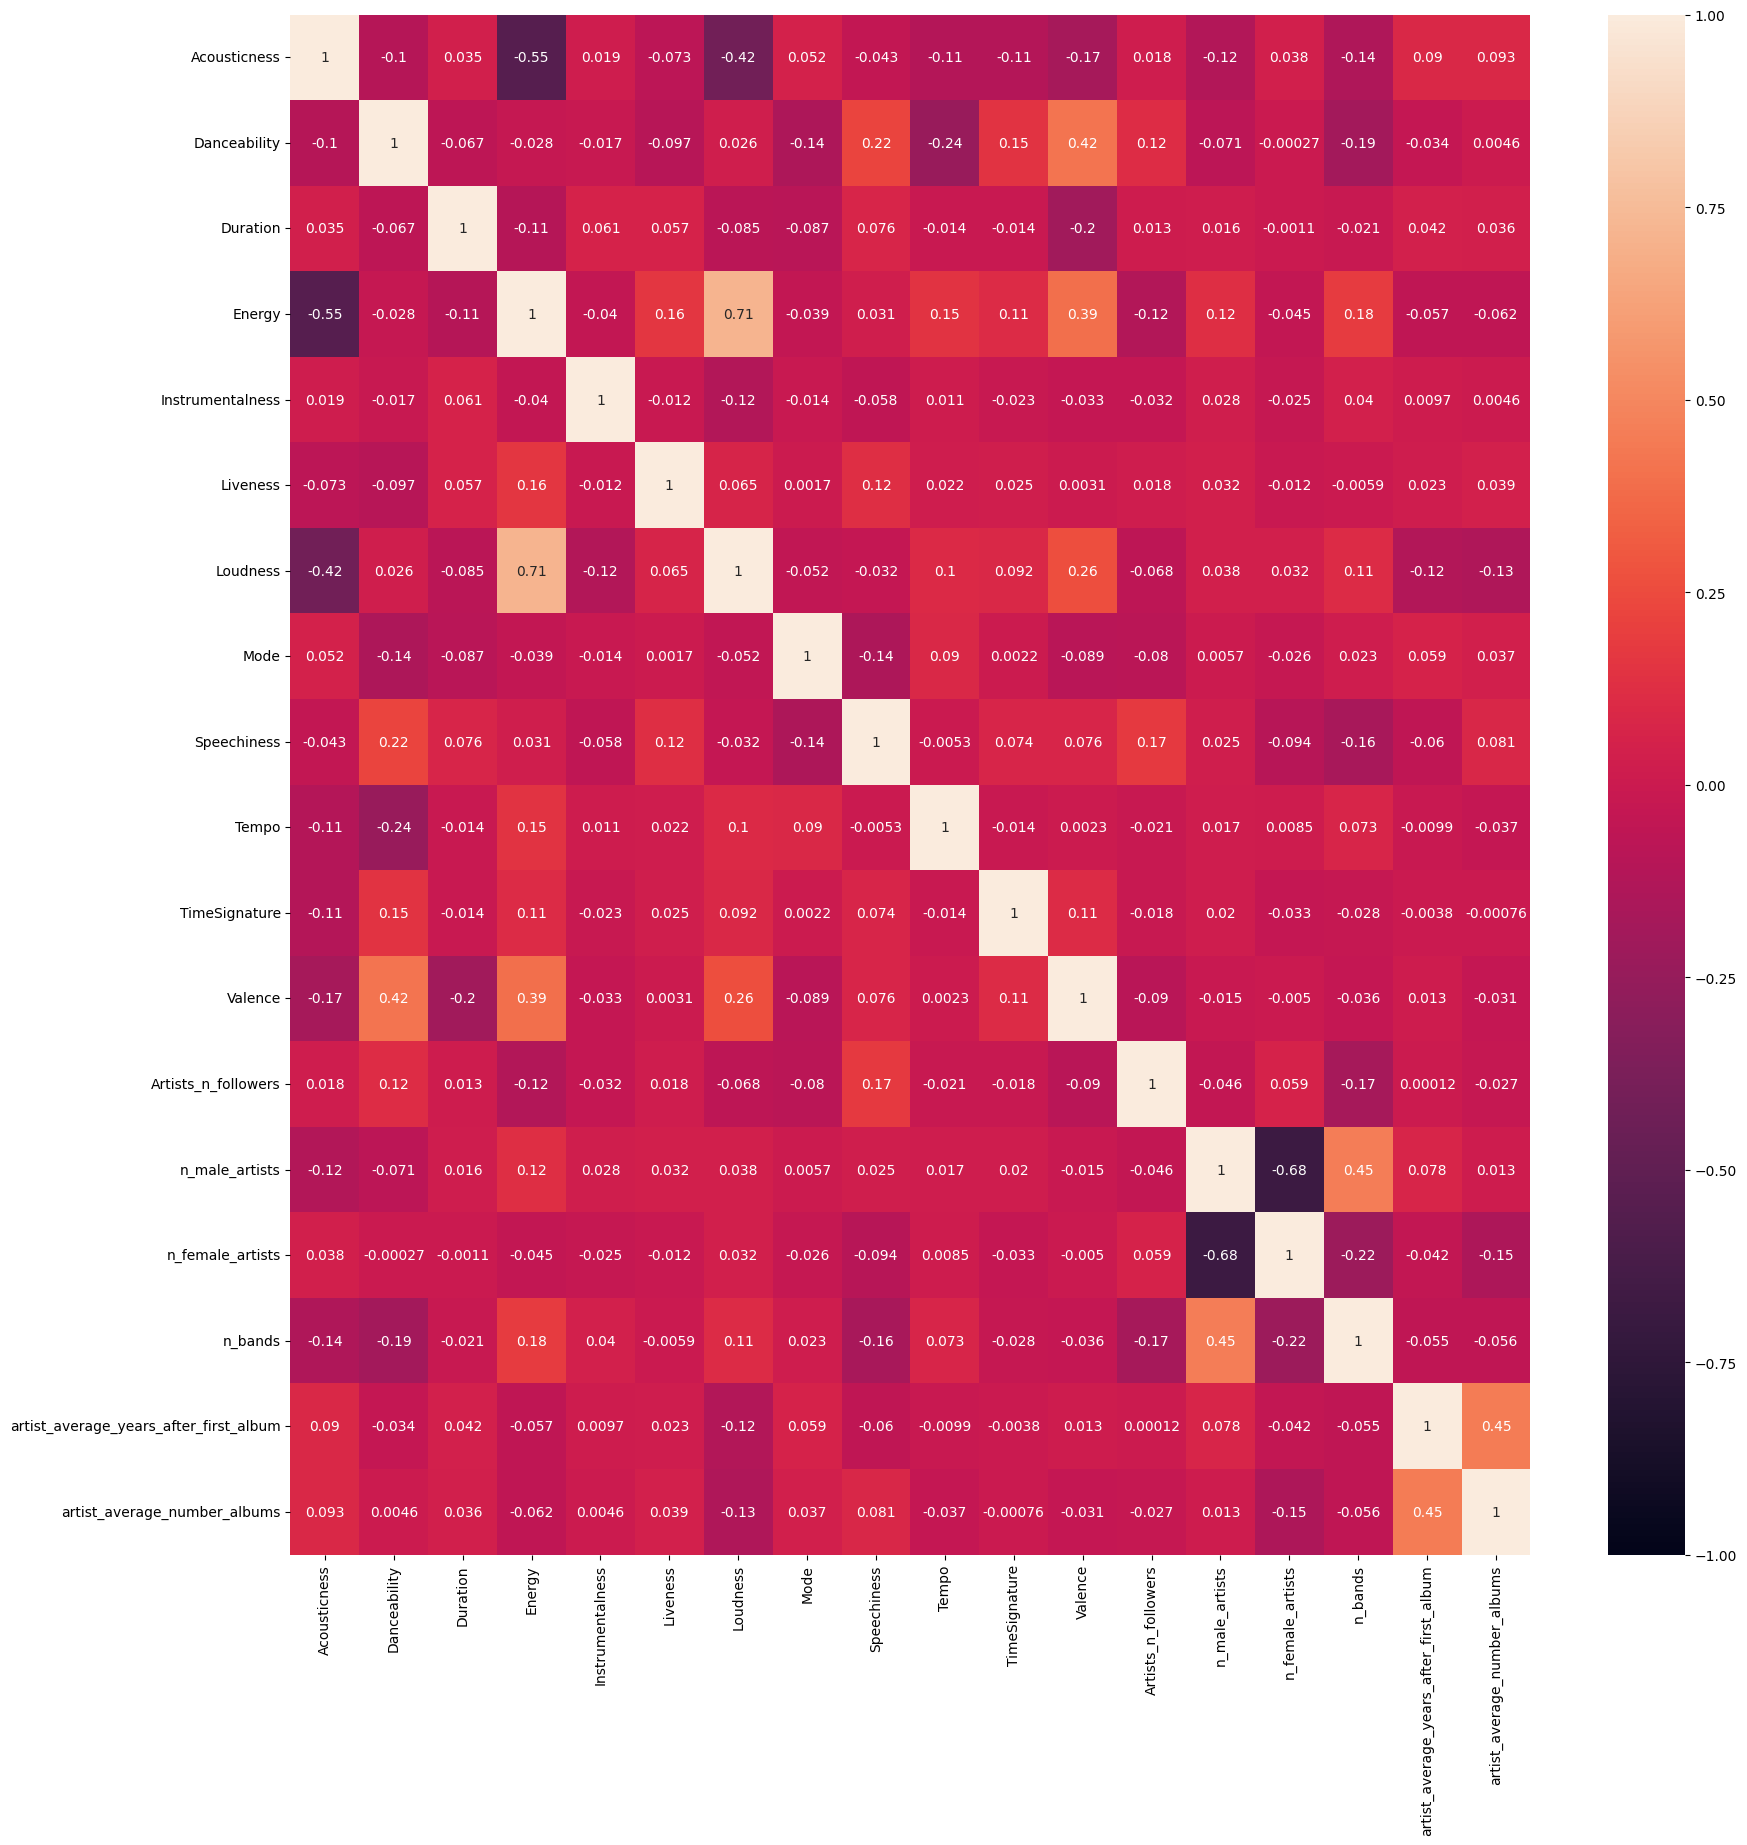

In [229]:
plt.figure(figsize=(20,20))
sns.heatmap(data=songIntegrate_df[df_num_list].corr(), annot=True, vmax=1, vmin=-1)
plt.show()

#### Check for data redundancy between numerical and categorical attributes

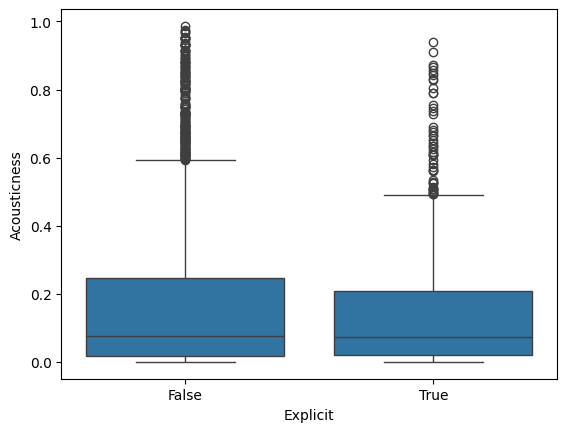

P-value: 0.0021212178717902345
-----------------divide-------------------


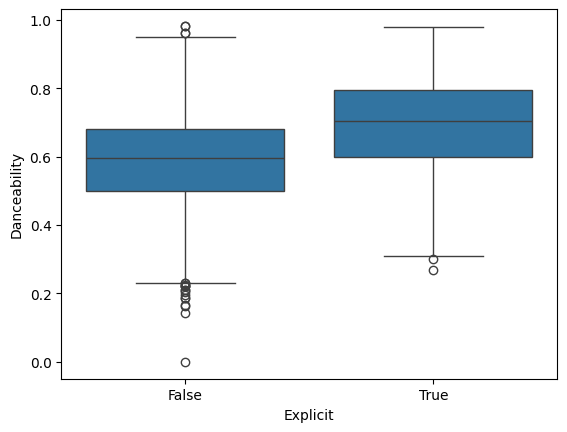

P-value: 6.706142154017309e-72
-----------------divide-------------------


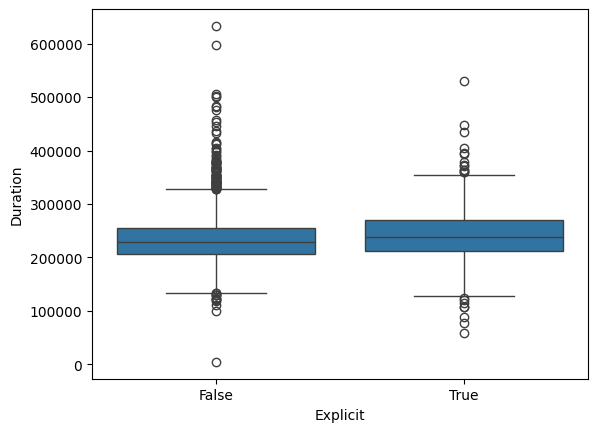

P-value: 5.026838650766435e-06
-----------------divide-------------------


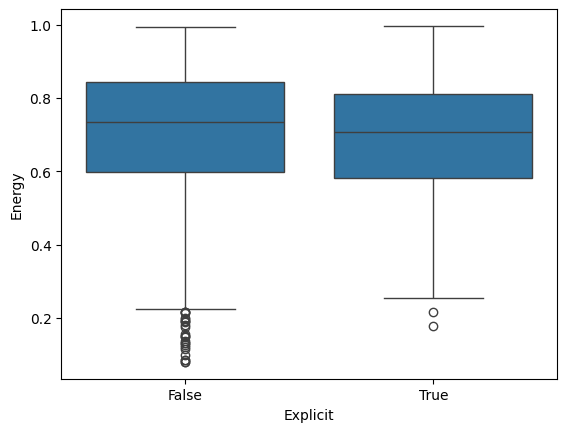

P-value: 0.01894792045049547
-----------------divide-------------------


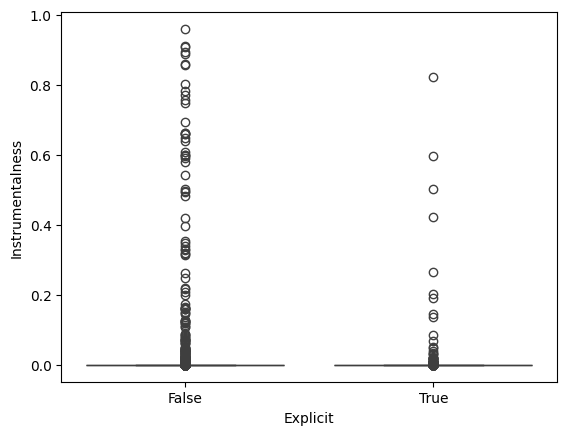

P-value: 0.02269307259084155
-----------------divide-------------------


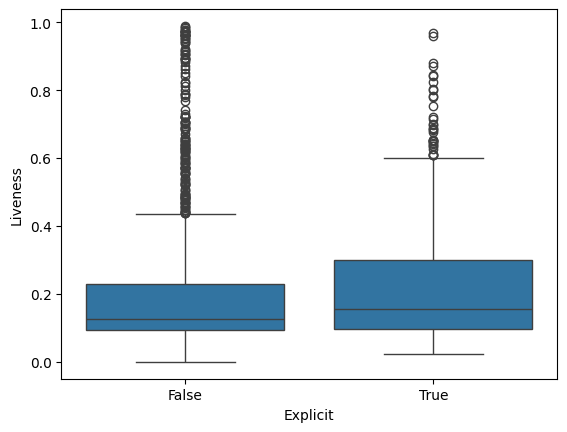

P-value: 2.815538753836128e-06
-----------------divide-------------------


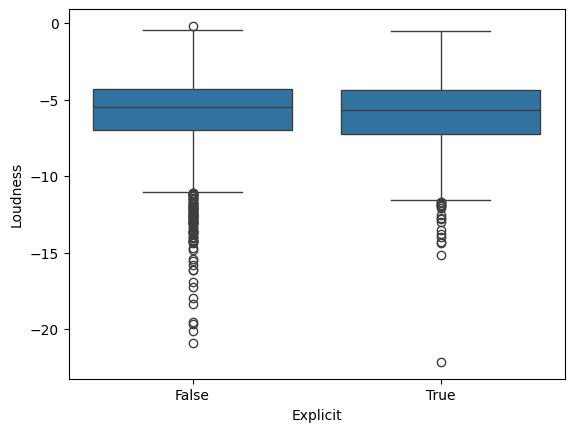

P-value: 0.1978668718887337
-----------------divide-------------------


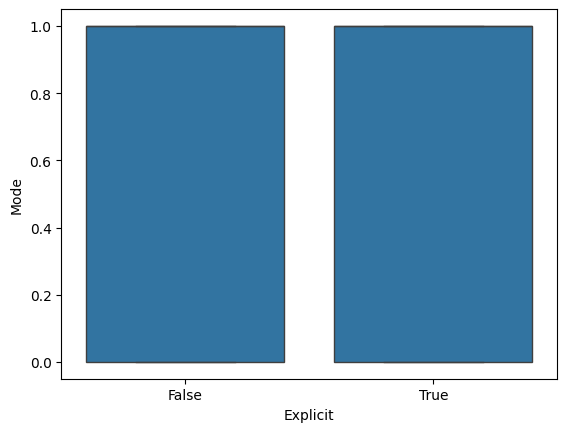

P-value: 4.186636356832512e-17
-----------------divide-------------------


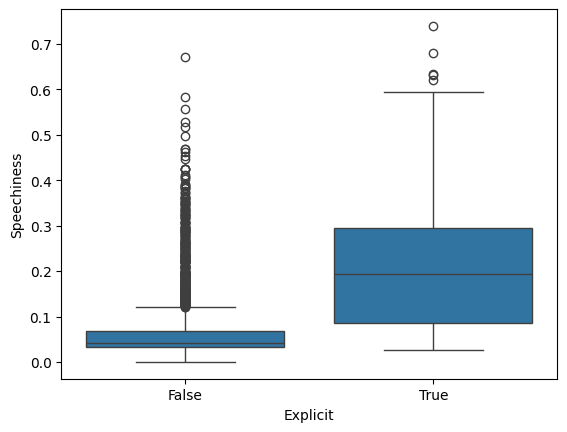

P-value: 3.489405909772897e-280
-----------------divide-------------------


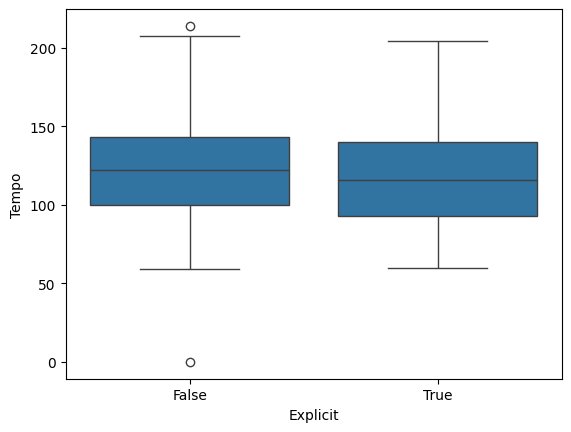

P-value: 6.223292219614281e-05
-----------------divide-------------------


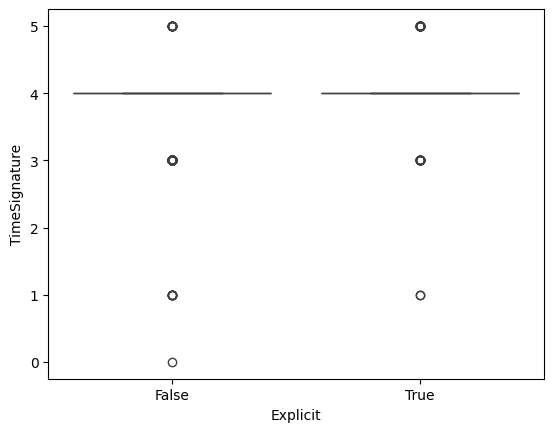

P-value: 0.00013911207989013142
-----------------divide-------------------


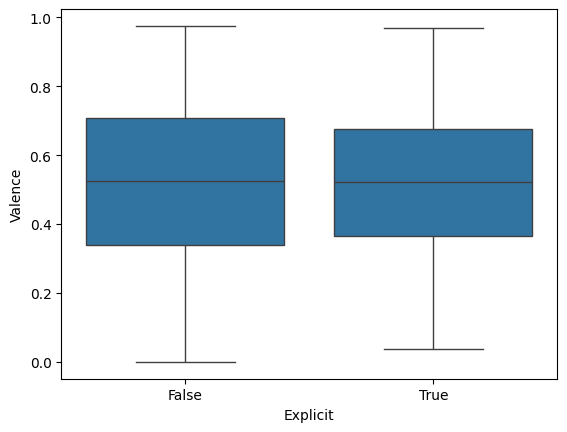

P-value: 0.32745416178613673
-----------------divide-------------------


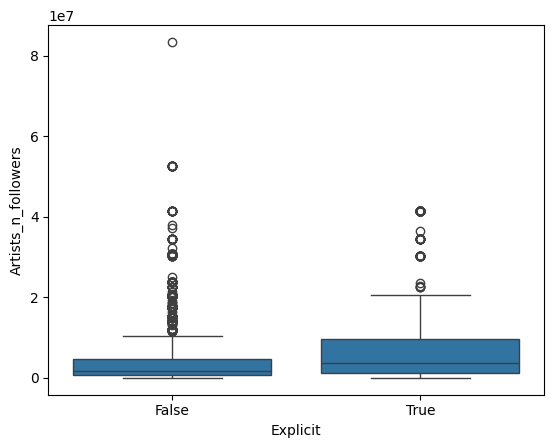

P-value: 1.1606660334902296e-40
-----------------divide-------------------


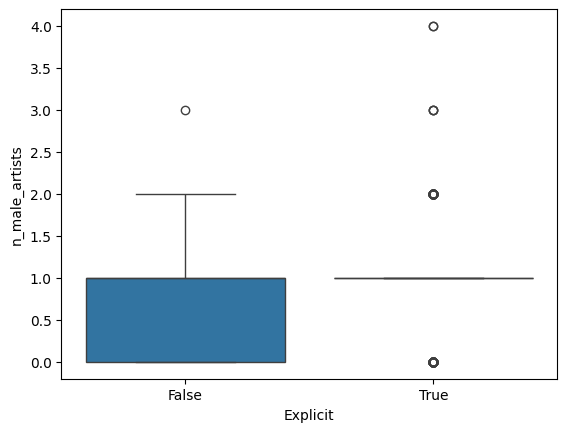

P-value: 2.2364045907459883e-07
-----------------divide-------------------


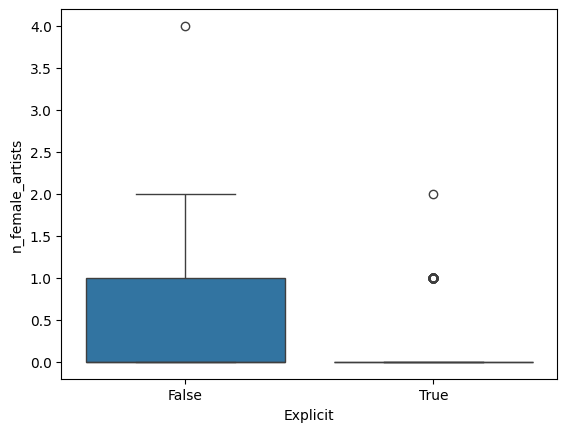

P-value: 5.214876802490455e-22
-----------------divide-------------------


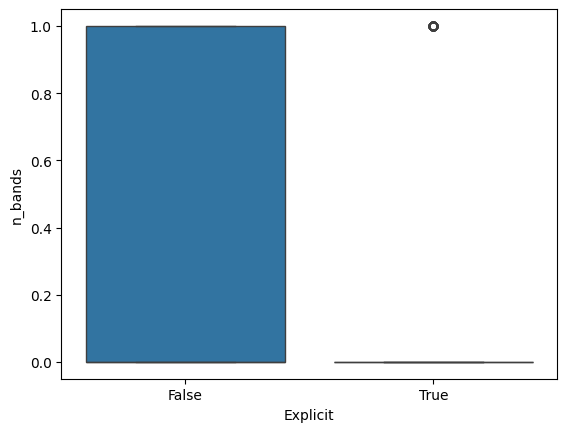

P-value: 4.5316093922262637e-26
-----------------divide-------------------


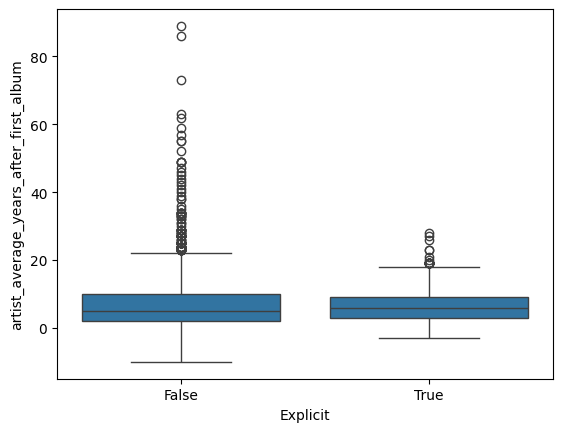

P-value: 0.00046625490289320317
-----------------divide-------------------


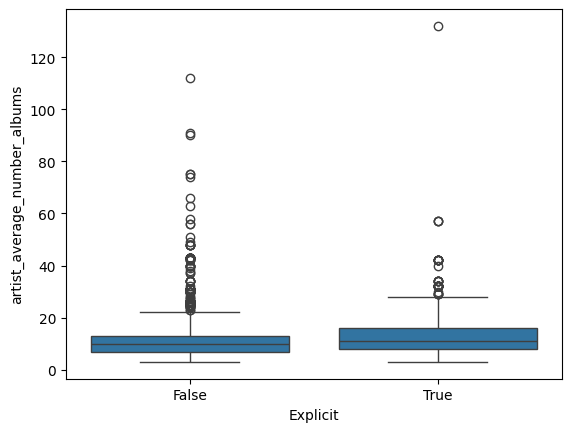

P-value: 7.452827544119422e-11
-----------------divide-------------------


In [237]:
from scipy.stats import ttest_ind

for n_att in df_num_list:
    sns.boxplot(data=songIntegrate_df,
               y=n_att, x='Explicit')
    plt.show()
    
    BM = songIntegrate_df['Explicit'] == True
    print(f"P-value: {ttest_ind(songIntegrate_df[BM][n_att],songIntegrate_df[~BM][n_att])[1]}")
    print('-----------------divide-------------------')

* Loudness, Valence do not have a relationship with Explicit

## The analysis
### Data Visualization approach to finding patterns of top songs

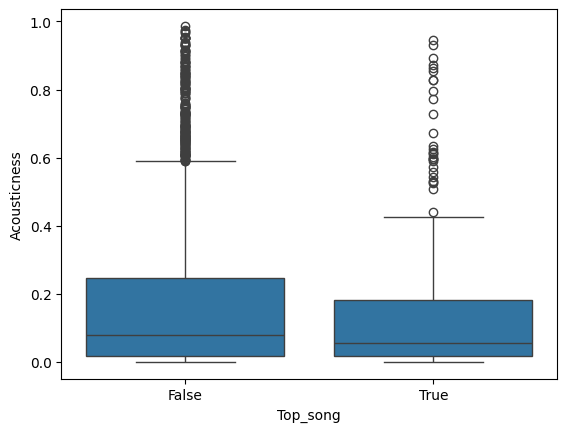

P-value: 0.0025679314421563383
{'not Top Song Median': 0.0787, 'Top Song Median': 0.05625}
-----------------divide-------------------


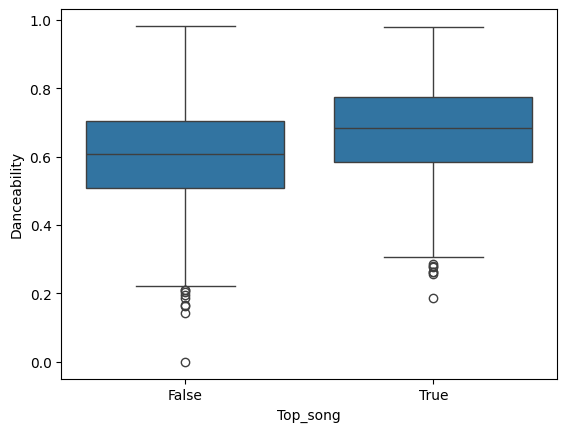

P-value: 2.146261725135309e-17
{'not Top Song Median': 0.609, 'Top Song Median': 0.683}
-----------------divide-------------------


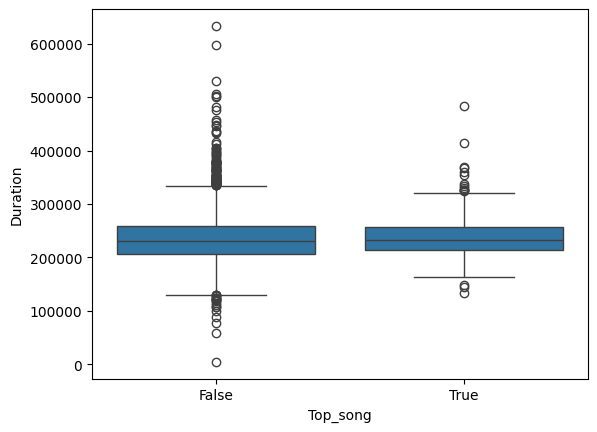

P-value: 0.2716247267616522
{'not Top Song Median': 230966.5, 'Top Song Median': 232887.0}
-----------------divide-------------------


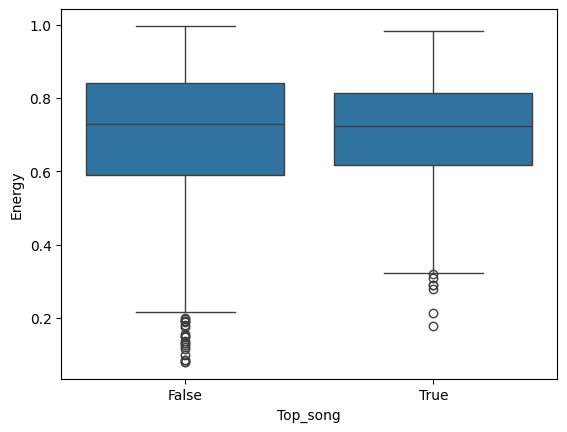

P-value: 0.6635095861831166
{'not Top Song Median': 0.729, 'Top Song Median': 0.7235}
-----------------divide-------------------


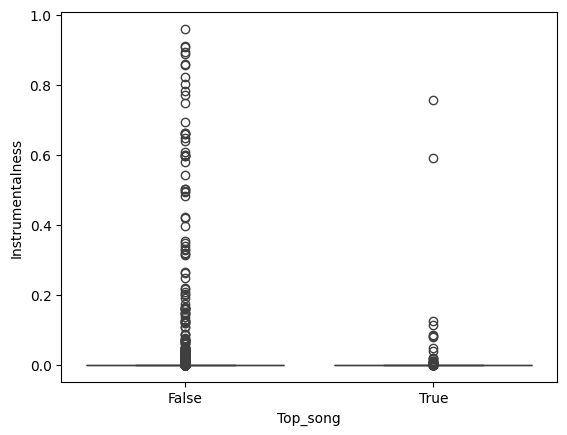

P-value: 0.18301436303358298
{'not Top Song Median': 0.0, 'Top Song Median': 0.0}
-----------------divide-------------------


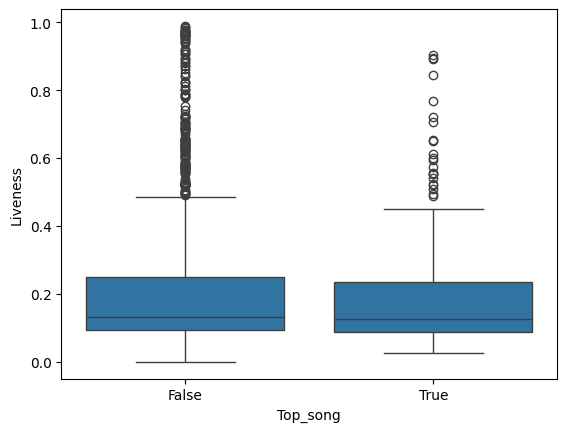

P-value: 0.2789479220513541
{'not Top Song Median': 0.131, 'Top Song Median': 0.125}
-----------------divide-------------------


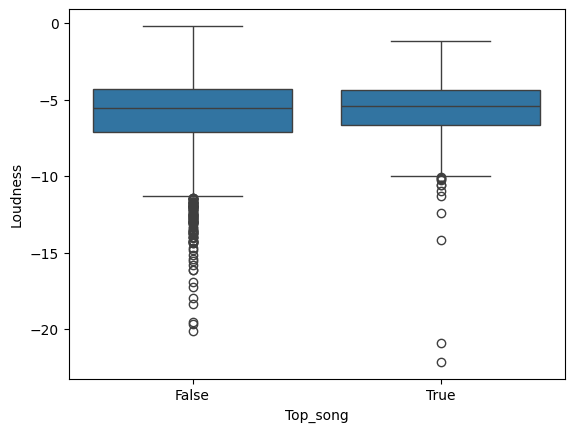

P-value: 0.09846527862629283
{'not Top Song Median': -5.54, 'Top Song Median': -5.4155}
-----------------divide-------------------


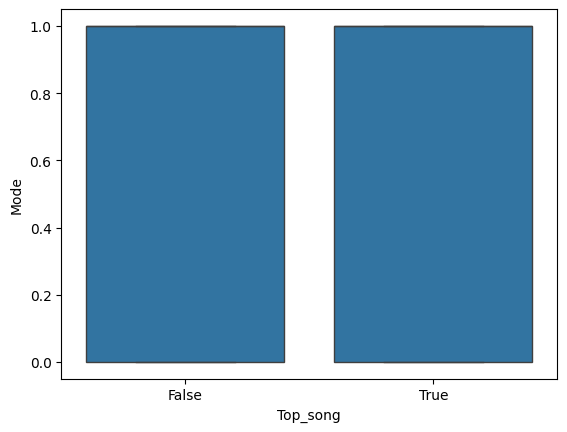

P-value: 4.85917585542875e-09
{'not Top Song Median': 1.0, 'Top Song Median': 1.0}
-----------------divide-------------------


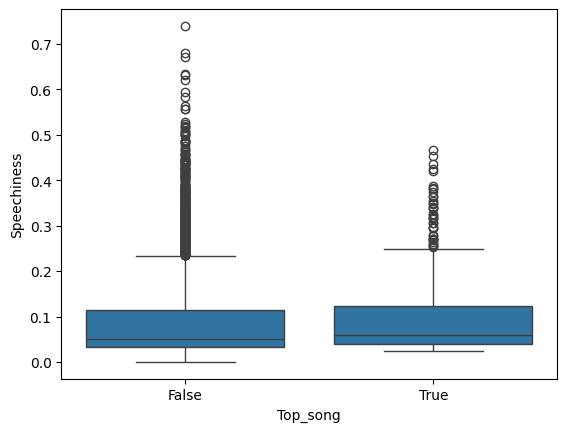

P-value: 0.6745542829738274
{'not Top Song Median': 0.0496, 'Top Song Median': 0.059899999999999995}
-----------------divide-------------------


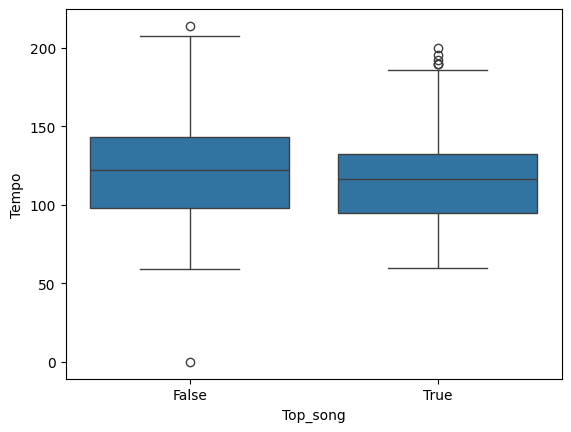

P-value: 0.00028480083660430535
{'not Top Song Median': 121.956, 'Top Song Median': 116.737}
-----------------divide-------------------


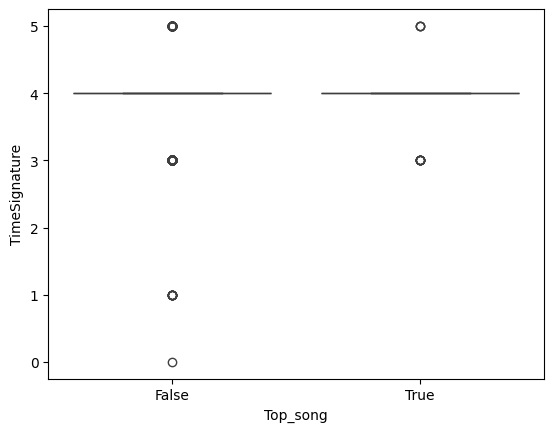

P-value: 0.20060062504262197
{'not Top Song Median': 4.0, 'Top Song Median': 4.0}
-----------------divide-------------------


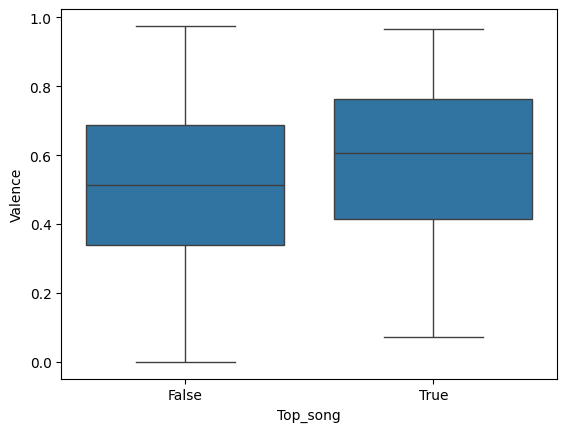

P-value: 9.468938344580322e-09
{'not Top Song Median': 0.512, 'Top Song Median': 0.605}
-----------------divide-------------------


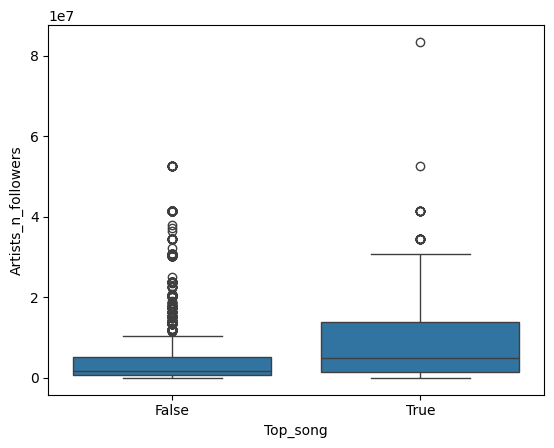

P-value: 4.468064528017653e-13
{'not Top Song Median': 1781499.0, 'Top Song Median': 4831233.0}
-----------------divide-------------------


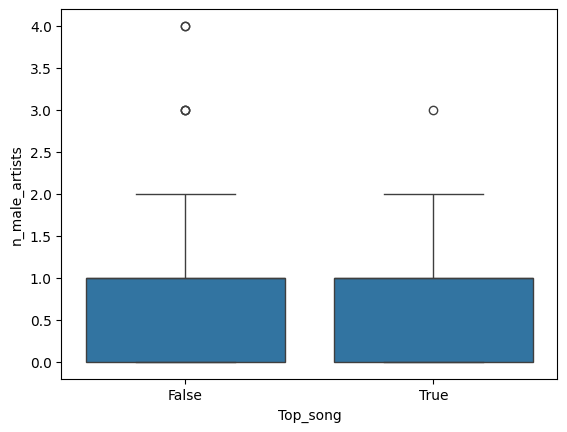

P-value: 0.00014395148618648768
{'not Top Song Median': 1.0, 'Top Song Median': 1.0}
-----------------divide-------------------


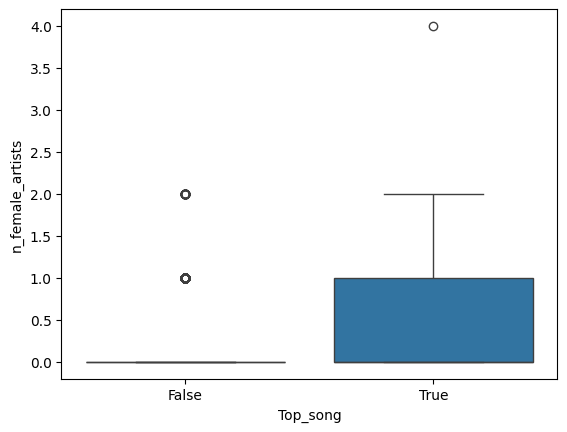

P-value: 2.5711930087045337e-08
{'not Top Song Median': 0.0, 'Top Song Median': 0.0}
-----------------divide-------------------


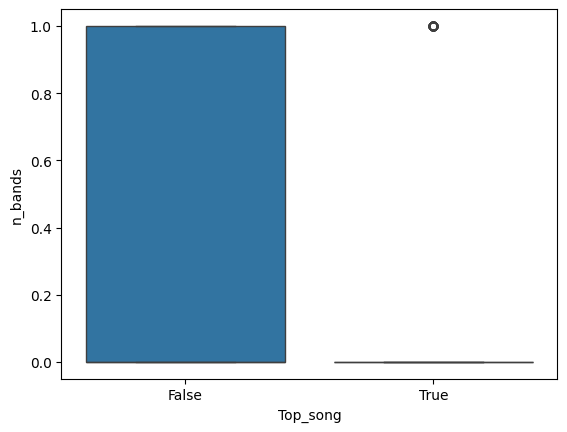

P-value: 0.007740966310447935
{'not Top Song Median': 0.0, 'Top Song Median': 0.0}
-----------------divide-------------------


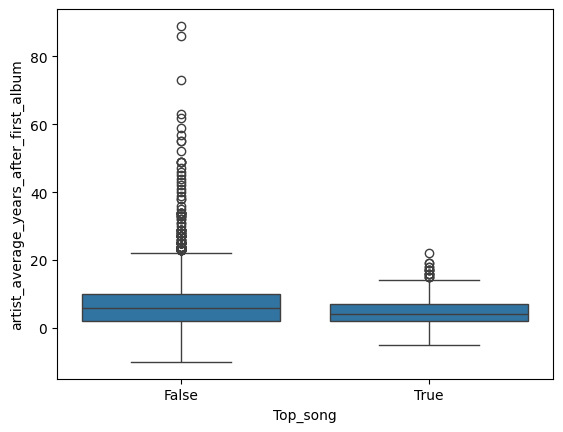

P-value: 1.9095869641320032e-09
{'not Top Song Median': 6.0, 'Top Song Median': 4.0}
-----------------divide-------------------


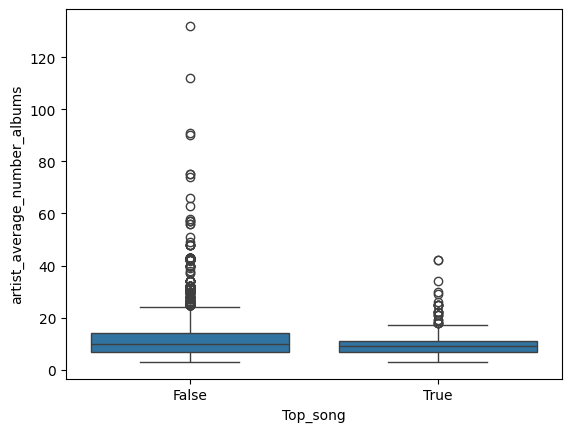

P-value: 1.3420996746592395e-06
{'not Top Song Median': 10.0, 'Top Song Median': 9.0}
-----------------divide-------------------


In [242]:
from scipy.stats import ttest_ind

for n_att in df_num_list:
    sns.boxplot(data=songIntegrate_df, 
                y=n_att,x='Top_song')
    plt.show()
    
    BM = songIntegrate_df.Top_song == True
    print(f"P-value: {(ttest_ind(songIntegrate_df[BM][n_att],songIntegrate_df[~BM][n_att])[1])}")
    dic = {'not Top Song Median': 
           songIntegrate_df[~BM][n_att].median(),
           'Top Song Median': 
           songIntegrate_df[BM][n_att].median()}
    print(dic)
    
    print('-----------------divide-------------------')

* Relationship: Acousticness, Danceability, Mode, Tempo, Valence,
  Artists_n_followers, n_male_artists, n_female_artists, n_bands,
  artist_average_years_after_first_album, artist_average_number_albums

* No relationship: Duration, Energy, Instrumentalness, Liveness, Loudness
  Speechiness, TimeSignature

In [243]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    songIntegrate_df.Top_song, songIntegrate_df.Explicit)

print(contingency_table)
print('p-value = {}'.format(
    chi2_contingency(contingency_table)[1]))

Explicit  False  True 
Top_song              
False      2544    736
True        304     88
p-value = 1.0


* No relationship: Explicit

### Decision Tree approach to finding multivariate patterns of top songs

In [247]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

y = songIntegrate_df.Top_song.replace(
    {True:'Top Song',False:'Not Top Song'})
Xs = songIntegrate_df.drop(columns = [
    'Name','Artists','Top_song','First_date_on_Billboard'])

classTree = DecisionTreeClassifier(criterion= 'entropy', 
                                   max_depth= 10,
                                   min_samples_split= 30,
                                   splitter= 'best')
classTree.fit(Xs, y)

dot_data = export_graphviz(classTree, 
                           out_file=None, 
                           feature_names=Xs.columns,  
                           class_names=['Not Top Song',
                                        'Top Song'], 
                           filled=True,
                           rounded=True, 
                           special_characters=True)  
graph = graphviz.Source(dot_data) 
graph.render(filename='TopSongDT')

'TopSongDT.pdf'